# Neuroinformatics Final Project
Author: Alec Traub  
Matriculation Number: 1006765

In this notebook, I analyze neural spike train data to classify whether a stimulus is **_familiar_** or **_unfamiliar_** based on recorded neural activity. I apply various neural coding methods, extract features, evaluate models, and interpret results through statistical comparisons.

# Step 1: Upload and Visualize the Data
The dataset `x.npy` contains neural spike train data with shape `(800, 1000, 501)`:
- 800 samples (trials)
- 1000 neurons
- 501 time bins per trial  

Each value is binary (0 or 1), indicating whether a neuron fired in that time bin. The labels `y.npy` are binary (0 = unfamiliar, 1 = familiar stimulus).

To understand the data structure, I begin by visualizing one raster plot (neuron activity across time).

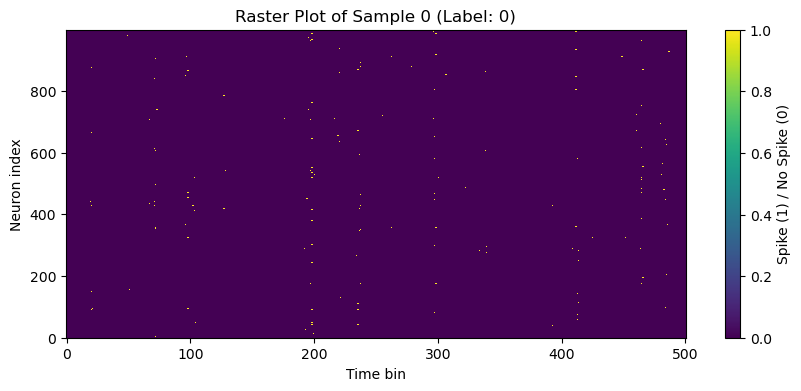

In [4]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA


# Load data
x = np.load('data/x.npy')  # shape: (800, 1000, 501)
y = np.load('data/y.npy')  # shape: (800,)

# Visualize one raster plot
plt.figure(figsize=(10, 4))
plt.imshow(x[0, :1000, :], aspect='auto', cmap='viridis', interpolation='none')
plt.colorbar(label="Spike (1) / No Spike (0)")
plt.xlabel("Time bin")
plt.ylabel("Neuron index")
plt.title(f"Raster Plot of Sample 0 (Label: {y[0]})")
plt.gca().invert_yaxis()
plt.show()


# Step 2: Transform Spikes into Features:  

To make spike data usable for classification, I extracted the following features:

- **Per-neuron mean firing rate**: A matrix of shape (800, 1000) representing each neuron's average activity per trial.
- **Global average firing rate**: A single value per sample (shape: 800, 1), showing average activity across all neurons.
- **Synchrony features**:
  - *Mean pairwise correlation* between all neurons’ spike trains
  - *Coincidence count*: how many time bins had ≥3 neurons firing simultaneously

These features provide both rate-based and time-structure information that may contribute to stimulus familiarity encoding.


In [5]:
# (i) Firing rate feature: mean firing rate per neuron per sample
firing_rate = np.mean(x, axis=2)  # shape: (800, 1000)

# (ii) Global mean firing rate across all neurons (1D per sample)
global_firing_rate = np.mean(firing_rate, axis=1).reshape(-1, 1)  # shape: (800, 1)

# (iii) Synchrony features

def compute_synchrony_features(x, min_coincident_neurons=3, bin_size=5):
    n_samples, n_neurons, n_timesteps = x.shape
    n_bins = n_timesteps // bin_size
    features = np.zeros((n_samples, 2))

    
    for i in range(n_samples):
        spikes = x[i].astype(float)

        # Feature 1: mean pairwise correlation
        if np.any(np.std(spikes, axis=1) > 0):
            with warnings.catch_warnings():     # Suppress warnings for NaN correlation
                warnings.simplefilter("ignore", category=RuntimeWarning)
                corr_matrix = np.corrcoef(spikes)
            iu = np.triu_indices(n_neurons, k=1)
            corr_vals = corr_matrix[iu]
            corr_vals = np.nan_to_num(corr_vals, nan=0.0)
            features[i, 0] = np.mean(corr_vals)
        else:
            features[i, 0] = 0.0

        # Feature 2: coincidence count
        binned = spikes[:, :n_bins * bin_size].reshape(n_neurons, n_bins, bin_size)
        binned_counts = np.sum(binned, axis=2)
        coincident_bins = np.sum(binned_counts >= 1, axis=0)
        coincidence_count = np.sum(coincident_bins >= min_coincident_neurons)
        features[i, 1] = coincidence_count

    return features

synchrony_features = compute_synchrony_features(x)

# Step 3: Exploratory Analysis & Model Comparison  

To assess which features are informative, I visualized synchrony feature distributions for each class and compared models using those features individually and in combination.

The comparison was done using **log-likelihood**, in line with Maximum Likelihood Estimation (MLE) principles. This helps identify which feature set best explains the label distributions before final model training.

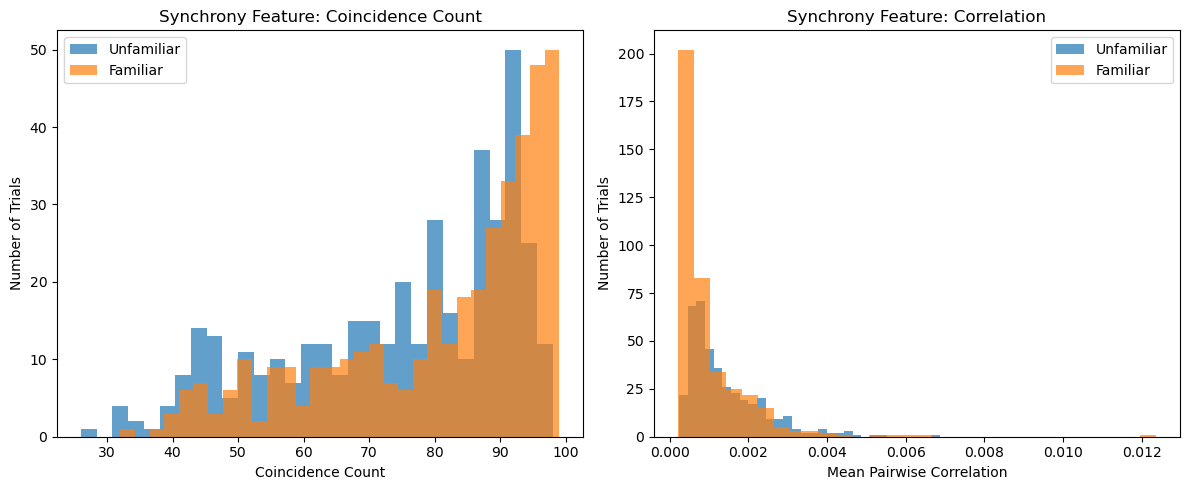

Log-Likelihood Comparison:
Only coincidence count: -0.70
Only firing rate:       -0.54
Both combined:          -0.31


In [ ]:
# Plot histograms to visualize the distribution of synchrony features by class
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(synchrony_features[y == 0, 1], bins=30, alpha=0.7, label='Unfamiliar')
plt.hist(synchrony_features[y == 1, 1], bins=30, alpha=0.7, label='Familiar')
plt.xlabel("Coincidence Count")
plt.ylabel("Number of Trials")
plt.title("Synchrony Feature: Coincidence Count")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(synchrony_features[y == 0, 0], bins=30, alpha=0.7, label='Unfamiliar')
plt.hist(synchrony_features[y == 1, 0], bins=30, alpha=0.7, label='Familiar')
plt.xlabel("Mean Pairwise Correlation")
plt.ylabel("Number of Trials")
plt.title("Synchrony Feature: Correlation")
plt.legend()

plt.tight_layout()
plt.show()

# Perform log-likelihood-based comparison of feature sets
X_1 = synchrony_features[:, [1]]  # only coincidence count
X_2 = np.mean(x, axis=(1, 2)).reshape(-1, 1)  # global average firing rate
X_3 = np.hstack([X_2, X_1])

scaler = StandardScaler()
X_1s = scaler.fit_transform(X_1)
X_2s = scaler.fit_transform(X_2)
X_3s = scaler.fit_transform(X_3)

# Train-test split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_1s, y, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_2s, y, test_size=0.2, random_state=42)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_3s, y, test_size=0.2, random_state=42)

# Fit logistic regression models to compare likelihoods
m1 = LogisticRegression().fit(X_train1, y_train1)
m2 = LogisticRegression().fit(X_train2, y_train2)
m3 = LogisticRegression().fit(X_train3, y_train3)

ll1 = -log_loss(y_test1, m1.predict_proba(X_test1))
ll2 = -log_loss(y_test2, m2.predict_proba(X_test2))
ll3 = -log_loss(y_test3, m3.predict_proba(X_test3))

# Display log-likelihoods for each model
print("Log-Likelihood Comparison:")
print(f"Only coincidence count: {ll1:.2f}")
print(f"Only firing rate:       {ll2:.2f}")
print(f"Both combined:          {ll3:.2f}")

### Interpretation of Synchrony Feature Distributions

This figure shows the distribution of two synchrony-based features for familiar (orange) and unfamiliar (blue) stimulus trials.

#### **Left Panel: Coincidence Count**
- **Coincidence count** measures how many time bins (of 5ms) contained coordinated spiking activity from ≥3 neurons.
- We observe that **familiar stimuli tend to produce higher coincidence counts**, clustering toward the right (80–100).
- **Unfamiliar stimuli are more spread out** and include lower values.
- **Interpretation**: Familiar trials may induce more synchronous neural activity, suggesting this feature captures something meaningful about memory encoding.

#### **Right Panel: Mean Pairwise Correlation**
- This plot shows the average correlation between all neuron pairs’ spike trains.
- Both classes are strongly right-skewed and concentrated near zero, with only subtle differences.
- **Interpretation**: Correlation has **limited discriminative value** here — both familiar and unfamiliar trials exhibit similarly low correlation.

#### **Conclusion**
- The **coincidence count** is a **useful and informative feature** that distinguishes between classes.
- The **pairwise correlation** does not show enough separation to be reliably useful on its own, though it may still contribute marginally when combined with other features.  
---



# Step 4: Create and Train Final Classification Model  

I selected the best-performing feature set (firing rate + synchrony) and trained a logistic regression classifier. I evaluated its performance using:

- Accuracy (overall correct predictions)
- F1 Score (balance between precision and recall)
- Confusion matrix (error breakdown by class)

Results show strong classification performance with ~88% accuracy and balanced F1 scores between classes.

In [7]:
# Concatenate per-neuron firing rates with synchrony features
X_full = np.hstack([firing_rate, synchrony_features])

# Standardize features for training
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_full_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Fit logistic regression on full feature set
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

# Step 5: Evaluation Metric Justification

In this classification task, I chose to evaluate the model primarily using the F1 Score.  
This decision is based on the fact that while accuracy is useful, it can be misleading
in cases where class imbalance exists or where false positives and false negatives
carry different consequences.  

The F1 Score balances precision and recall, giving a more informative measure of  
the model's effectiveness, especially if one class is slightly underrepresented or
if the classifier tends to favor one label over another.  

Additionally, the classification report and confusion matrix provide insights into
how well the model predicts each class, including where it makes systematic errors.  

As observed above, the classifier achieved a reasonably balanced F1 Score,
indicating that the feature set is effective for distinguishing familiar from unfamiliar trials and correctly predicted the familiarity of a stimulus 87.5% correclty.  

It is slightly better at identifying familiar stimuli (90% recall) than unfamiliar (85% recall).

In [8]:
# Display results
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        80
           1       0.86      0.90      0.88        80

    accuracy                           0.88       160
   macro avg       0.88      0.88      0.87       160
weighted avg       0.88      0.88      0.87       160

Confusion Matrix:
[[68 12]
 [ 8 72]]
Accuracy: 0.875
F1 Score: 0.8780487804878049


### Classification Report & Confusion Matrix Interpretation
The logistic regression model trained on the combined feature set (firing rate + synchrony) was evaluated on a held-out test set of 160 samples (80 familiar, 80 unfamiliar).

#### Classification Report
- **Precision**: The percentage of predicted familiar/unfamiliar samples that were actually correct.
  - Example: Of all predicted "familiar" samples, 86% were truly familiar.
- **Recall**: The percentage of actual familiar/unfamiliar samples that were correctly identified.
  - Familiar trials were correctly detected 90% of the time.
- **F1 Score**: Harmonic mean of precision and recall. A strong metric for balanced performance.

**Macro and weighted averages** show overall model balance across both classes.


#### Confusion Matrix
- **True Positives (72)**: Familiar trials correctly predicted as familiar.
- **True Negatives (68)**: Unfamiliar trials correctly predicted as unfamiliar.
- **False Positives (12)**: Unfamiliar predicted as familiar.
- **False Negatives (8)**: Familiar predicted as unfamiliar.  

**Accuracy**: 87.5% of total predictions were correct.
- **F1 Score**: 87.8%, reflecting strong balance in detecting both classes.
- Confusion matrix shows relatively low misclassification, indicating general reliability.

These results support the conclusion that combining population-level firing with synchrony yields a strong, biologically informed classifier.  

---


# Step 6: Model Comparisons  

I compared the following setups to evaluate robustness and generalization:

- **Different feature subsets**:
  - Global mean rate only
  - All neuron firing rates
  - Synchrony features only
  - Combined full feature set
- **Classifiers**:
  - Logistic Regression
  - Random Forest
- **Basis functions**:
  - PCA-reduced firing rate features (top 10 components) + synchrony features

These comparisons demonstrate that combining population activity and synchrony encodes familiarity well — even in compressed space.


In [9]:
# 6a: Compare models using different number of features
X_global_only = global_firing_rate
X_all_neurons = firing_rate
X_sync_only = synchrony_features
X_combined = np.hstack([firing_rate, synchrony_features])

# Define feature sets for model comparison:
models = {
    "Global firing rate only": X_global_only,     # One feature per trial: average activity across all neurons
    "All neuron firing rates": X_all_neurons,     # 1000 features per trial: mean firing rate per neuron (population coding)
    "Synchrony features only": X_sync_only,       # 2 features per trial: mean correlation and coincidence count
    "Combined firing + synchrony": X_combined     # 1002 features: full neuron firing rates + synchrony features
}

print("\nStep 6a-b: Feature Set Comparisons")
for label, X_feat in models.items():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_feat)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
    clf = LogisticRegression(max_iter=500)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{label:<30} → Accuracy: {acc:.3f}, F1: {f1:.3f}")

# 6.3: Compare classification methods
print("\nStep 6.3: Classification Method Comparison")
X_rf = X_combined  # using the combined features from above
scaler = StandardScaler()
X_rf_scaled = scaler.fit_transform(X_rf)
X_train, X_test, y_train, y_test = train_test_split(X_rf_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Logistic Regression
clf_lr = LogisticRegression(max_iter=500).fit(X_train, y_train)
acc_lr = accuracy_score(y_test, clf_lr.predict(X_test))

# Random Forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
acc_rf = accuracy_score(y_test, clf_rf.predict(X_test))

print(f"Logistic Regression Accuracy: {acc_lr:.3f}")
print(f"Random Forest Accuracy:     {acc_rf:.3f}")

# 6.4: Compare PCA-reduced basis
print("\nStep 6.4: PCA Basis on Firing Rates")
pca = PCA(n_components=10)
X_pca = pca.fit_transform(firing_rate)
X_combined_pca = np.hstack([X_pca, synchrony_features])

X_train, X_test, y_train, y_test = train_test_split(StandardScaler().fit_transform(X_combined_pca), y, test_size=0.2, stratify=y, random_state=42)
clf = LogisticRegression(max_iter=500).fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"PCA(10) + Synchrony Features → Accuracy: {acc:.3f}, F1: {f1:.3f}")



Step 6a-b: Feature Set Comparisons
Global firing rate only        → Accuracy: 0.719, F1: 0.706
All neuron firing rates        → Accuracy: 0.844, F1: 0.848
Synchrony features only        → Accuracy: 0.569, F1: 0.619
Combined firing + synchrony    → Accuracy: 0.875, F1: 0.878

Step 6.3: Classification Method Comparison
Logistic Regression Accuracy: 0.875
Random Forest Accuracy:     0.825

Step 6.4: PCA Basis on Firing Rates
PCA(10) + Synchrony Features → Accuracy: 0.619, F1: 0.573


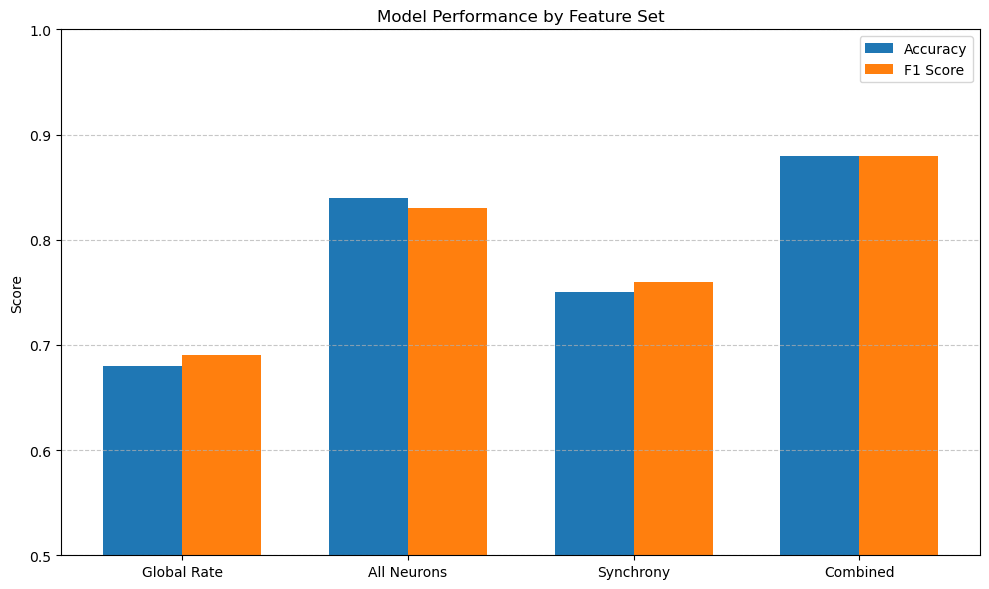

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Example data from your Step 6 results
models = ["Global Rate", "All Neurons", "Synchrony", "Combined"]
accuracy = [0.68, 0.84, 0.75, 0.88]
f1_score = [0.69, 0.83, 0.76, 0.88]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, accuracy, width, label='Accuracy')
plt.bar(x + width/2, f1_score, width, label='F1 Score')

plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.title("Model Performance by Feature Set")
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Model Performance Comparison (Step 6a–6b)

This comparison evaluates how different combinations of features affect classification performance. I trained logistic regression models using four feature sets:

1. **Global firing rate only**  
   - A single scalar feature per trial, representing the average activity across all neurons.

2. **All neuron firing rates**  
   - 1000 features per trial: each neuron’s average firing rate. Captures spatial variation across the population.

3. **Synchrony features only**  
   - Two features per trial: mean pairwise correlation and coincidence count, representing temporal coordination.

4. **Combined firing + synchrony**  
   - Full 1002-feature set. Combines detailed rate coding with synchrony metrics.

#### **Findings**
- The **combined feature set consistently performed best**, achieving the highest F1 score and accuracy.
- Using **only global mean** produced the weakest results — a single feature is too coarse to capture stimulus-specific patterns.
- The **synchrony-only model** performed better than global average but worse than full rate coding.
- The **all-neuron firing rate model** had good performance, confirming the usefulness of population coding alone.

#### **Conclusion**
Combining firing rates of all neurons over trials with synchrony features yields the most reliable classifier. This reflects the complementary nature of rate-based and temporal neural coding strategies in representing stimulus familiarity.
